In [1]:
%load_ext autoreload
%autoreload 2 

In [2]:
from pathlib import Path
from pyspark.sql import SparkSession, functions as F


def get_spark(cores=4, memory="16g"):
    spark = (
        SparkSession.builder.master(f"local[{cores}]")
        .config("spark.driver.memory", memory)
        .getOrCreate()
    )
    return spark


root = Path("~/scratch/trec-tot-2025").expanduser() / "data/enwiki/parquet"
spark = get_spark(8, "60g")

page = spark.read.parquet((root / "page").as_posix())
pagelinks = spark.read.parquet((root / "pagelinks").as_posix())
categorylinks = spark.read.parquet((root / "categorylinks").as_posix())
page.printSchema()
pagelinks.printSchema()
categorylinks.printSchema()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/07/12 18:16:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


root
 |-- page_id: integer (nullable = true)
 |-- page_namespace: integer (nullable = true)
 |-- page_title: string (nullable = true)
 |-- page_is_redirect: string (nullable = true)
 |-- page_is_new: string (nullable = true)
 |-- page_random: string (nullable = true)
 |-- page_touched: string (nullable = true)
 |-- page_links_updated: string (nullable = true)
 |-- page_latest: string (nullable = true)
 |-- page_len: string (nullable = true)
 |-- page_content_model: string (nullable = true)
 |-- page_lang: string (nullable = true)

root
 |-- pl_from: integer (nullable = true)
 |-- pl_from_namespace: integer (nullable = true)
 |-- pl_target_id: integer (nullable = true)

root
 |-- cl_from: integer (nullable = true)
 |-- cl_to: string (nullable = true)
 |-- cl_sortkey: string (nullable = true)
 |-- cl_timestamp: string (nullable = true)
 |-- cl_sortkey_prefix: string (nullable = true)
 |-- cl_collation: string (nullable = true)
 |-- cl_type: string (nullable = true)
 |-- cl_collation_id: 

So the first thing to figure out is the number of pages in general.
63 million pages is much larger than the 6 million articles.

In [3]:
page.count()

63415160

https://en.wikipedia.org/wiki/Wikipedia:Namespace

Of course. Here is the data from the image formatted as a Markdown table.

| Namespace ID | Name | Count | Description |
| :--- | :--- | :--- | :--- |
| **0** | **Main / Article** | 18,513,682 | The primary encyclopedia articles. |
| **1** | **Talk** | 10,048,437 | Discussion pages for main articles. |
| **2** | **User** | 4,494,865 | Personal pages for registered users. |
| **3** | **User talk** | 20,073,684 | Discussion pages for registered users. |
| **4** | **Wikipedia** | 1,505,178 | Pages related to the Wikipedia project itself. |
| **5** | **Wikipedia talk** | 208,737 | Discussion pages for project-related pages. |
| **6** | **File** | 982,032 | Pages describing media files (images, sounds). |
| **7** | **File talk** | 808,162 | Discussion pages for media files. |
| **10** | **Template** | 846,448 | Reusable content templates (e.g., infoboxes). |
| **11** | **Template talk** | 600,074 | Discussion pages for templates. |
| **14** | **Category** | 2,531,387 | Pages that are categories, listing other pages. |
| **15** | **Category talk** | 2,209,900 | Discussion pages for categories. |
| **100** | **Portal** | 104,568 | Gateway pages for broad subject areas. |
| **118** | **Draft** | 283,610 | Articles being drafted before being published. |
| **828** | **Module** | 18,225 | Scribunto modules for complex template logic. |

In [4]:
namespace_counts = page.groupBy("page_namespace").count().orderBy("page_namespace")
namespace_counts.show(100, False)

+--------------+--------+
|page_namespace|count   |
+--------------+--------+
|0             |18513682|
|1             |10048437|
|2             |4494865 |
|3             |20073684|
|4             |1505178 |
|5             |208737  |
|6             |982032  |
|7             |808162  |
|8             |2453    |
|9             |2199    |
|10            |846448  |
|11            |600074  |
|12            |2799    |
|13            |1662    |
|14            |2531387 |
|15            |2209900 |
|100           |104568  |
|101           |43294   |
|118           |283610  |
|119           |115956  |
|126           |2484    |
|127           |153     |
|710           |1971    |
|711           |212     |
|828           |18225   |
|829           |12948   |
|1728          |31      |
|1729          |9       |
+--------------+--------+



We then see what the breakdown is based on whether its a redirect or not._
We find out that there is some corruption when writing out the data to csv, since the `page_is_redirect` column has 294 unique values including 1 and 0.

In [5]:
is_redirect = (
    page.where(F.col("page_namespace") == 0).groupBy("page_is_redirect").count()
)
is_redirect.show()
print(f"total of {is_redirect.count()} unique values for page_is_redirect")

is_redirect.where(F.col("page_is_redirect").isin(["0", "1"])).show()

+--------------------+--------+
|    page_is_redirect|   count|
+--------------------+--------+
|             _S.252"|       2|
|               _Jr."|     175|
|                   0| 7016300|
|               _CEF"|      11|
|    _or_not_to_be"""|       1|
|        _Спрингваeл"|       6|
|                _Jr"|      20|
|_Baby!""_College_...|       1|
|           _Престон"|       2|
|          _Futskraj"|       6|
|                _SJ"|       2|
|         _the_elder"|       2|
|_Slavery_and_the_...|       1|
|                   1|11496703|
| _the_Best_There_Was|       4|
|            _Jordan"|       2|
|_ad_salutarem_und...|       1|
|_1st_Regiment_Ill...|       8|
| _Brown_and_UMaine)"|       1|
|    _Tiger_Lily?"")"|       1|
+--------------------+--------+
only showing top 20 rows


total of 294 unique values for page_is_redirect


+----------------+--------+
|page_is_redirect|   count|
+----------------+--------+
|               0| 7016300|
|               1|11496703|
+----------------+--------+



This is fairly close to the official number as of 2025-07-11 of 7,021,882.
The important thing is that we have all of the articles that are represented in the wikidata dump.
Let's check that this set is represented properly.

In [6]:
import json

gdrive_root = Path("~/scratch/trec-tot-2025").expanduser() / "data/gdrive/data"
# display(sorted(gdrive_root.glob("*")))
! ls -logh {gdrive_root.as_posix()}

data = json.loads((gdrive_root / "id2wikidataid_6m.json").read_text())
len(data)

id2wd = (
    spark.createDataFrame(data.items(), schema=["page_id", "wikidata_id"])
    .repartition(32)
    .cache()
)
id2wd.printSchema()

total 537M
-rw-r--r--. 1  23M Jun 18 18:06 corpus-first-1000.jsonl
-rw-r--r--. 1  53K Jun 25 01:59 dev1-gemini-25-flash.jsonl
-rw-r--r--. 1 362K Jun 25 01:47 dev3-gemini-25-flash.jsonl
-rw-r--r--. 1 160M Jun 30 01:26 id2wikidataid_6m.json
-rw-r--r--. 1 355M Jun 30 01:32 id_to_aliases.json
drwxr-xr-x. 6 4.0K Jul 10 16:08 shared_retrieval_results
root
 |-- page_id: string (nullable = true)
 |-- wikidata_id: string (nullable = true)



In [7]:
id2wd.count()

25/07/12 18:18:46 WARN TaskSetManager: Stage 21 contains a task of very large size (18040 KiB). The maximum recommended task size is 1000 KiB.


6407814

This takes about 2.5 minutes to do. 
Join the resulting mapping to our page dataset.

In [8]:
page_filtered = (
    page.where("page_namespace = 0")
    .where(F.col("page_is_redirect") == "0")
    .join(
        id2wd.select(
            F.col("page_id").cast("integer"), F.col("wikidata_id").cast("integer")
        ),
        on="page_id",
        how="inner",
    )
)
page_filtered.count()

6336917

So it looks like that there are (6407814 - 6336917 = 70897) articles that are actually redirects in the wikidata side.
Let's double check this.

In [9]:
page_filtered = page.join(
    id2wd.select(
        F.col("page_id").cast("integer"), F.col("wikidata_id").cast("integer")
    ),
    on="page_id",
    how="inner",
)
page_filtered.count()

6379997

We are missing 6407814 - 6379997 = 27817 articles from the wikidata dump.
I wonder why this is...

In any case, let's move forward and generate the edge list that we can work with.
We will use the wikidata ids as our node ids to minimize confusion down the line.

In [12]:
page_filtered = (
    page.where("page_namespace = 0")
    .where(F.col("page_is_redirect") == "0")
    .join(
        id2wd.select(F.col("page_id").cast("integer"), "wikidata_id"),
        on="page_id",
        how="inner",
    )
).cache()

pagelinks_filtered = (
    pagelinks.where("pl_from_namespace = 0")
    .join(
        page_filtered.select(
            F.col("page_id").alias("pl_from"), F.col("wikidata_id").alias("from")
        ),
        on="pl_from",
        how="inner",
    )
    .join(
        page_filtered.select(
            F.col("page_id").alias("pl_target_id"), F.col("wikidata_id").alias("to")
        ),
        on="pl_target_id",
        how="inner",
    )
).cache()
pagelinks_filtered.count()

118102388

Finally let's calculate the average in-degree and out-degree.
We can visualize the degree distributions as well.

+-------+-------+------------------+
|summary|   from|        out_degree|
+-------+-------+------------------+
|  count|6245984|           6245985|
|   mean|   NULL|18.908528918977552|
| stddev|   NULL| 28.00139087377321|
|    min|   Q100|                 1|
|    25%|   NULL|                 4|
|    50%|   NULL|                10|
|    75%|   NULL|                22|
|    max|Q999999|              1993|
+-------+-------+------------------+



Text(0.5, 1.0, 'Out-degree distribution (log-log scale)')

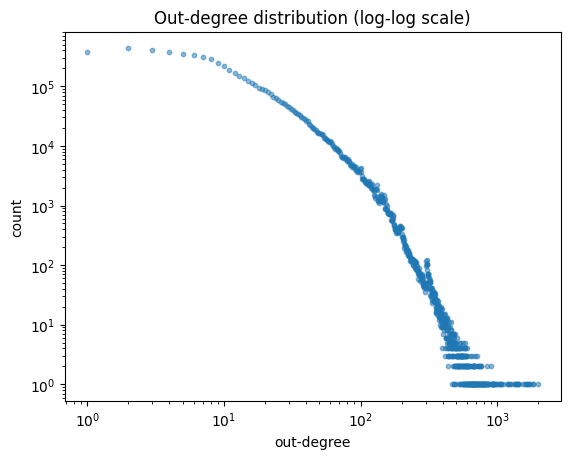

In [13]:
import matplotlib.pyplot as plt

degree = pagelinks_filtered.groupBy("from").agg(F.count("*").alias("out_degree"))
degree.summary().show()

# degree distribution
pdf = degree.groupBy("out_degree").count().orderBy("out_degree").toPandas()

# log-log plot
plt.scatter(pdf.out_degree, pdf["count"], alpha=0.5, s=10)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("out-degree")
plt.ylabel("count")
plt.title("Out-degree distribution (log-log scale)")

+-------+-------+------------------+
|summary|     to|         in_degree|
+-------+-------+------------------+
|  count|1734751|           1734752|
|   mean|   NULL|   68.080271992769|
| stddev|   NULL|1760.8100767327403|
|    min| Q10000|                 1|
|    25%|   NULL|                 1|
|    50%|   NULL|                 5|
|    75%|   NULL|                35|
|    max|Q999997|           1433674|
+-------+-------+------------------+



Text(0.5, 1.0, 'In-degree distribution (log-log scale)')

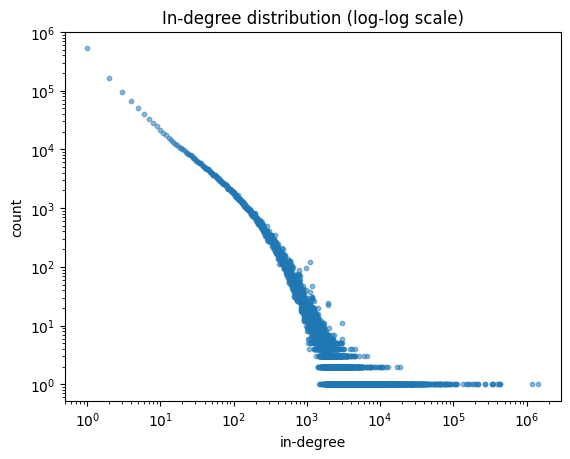

In [14]:
degree = pagelinks_filtered.groupBy("to").agg(F.count("*").alias("in_degree"))
degree.summary().show()

# degree distribution
pdf = degree.groupBy("in_degree").count().orderBy("in_degree").toPandas()

# log-log plot
plt.scatter(pdf.in_degree, pdf["count"], alpha=0.5, s=10)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("in-degree")
plt.ylabel("count")
plt.title("In-degree distribution (log-log scale)")